<a href="https://colab.research.google.com/github/CarisR/CarisR/blob/main/IoT_Sensor_Imputation_Benchmarking_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Imputation**

**Dataset**: IoT-Based Energy and Environmental Parameters in a Smart Building Infrastructure

**Source**: [github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure](https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure)

**Team**: Caris Rungkittikhun, Derrick O Nyagesuka, Lawrence K Lwanga \
**Institution**: Metropolitan State University \
**Instructor**: Professor Mousumi Munmun \
**Date last modified**: 2026/03/19

### **1. Main Imports**
This cell imports the essential libraries for data processing, machine learning, and advanced imputation. Key components include:

* **Core Utilities**: `os`, `glob`, and `warnings` for file handling and environment management.
* **Data Manipulation**: `pandas` and `numpy` for handling dataframes and numerical operations.
* **Visualization**: `matplotlib.pyplot` for generating plots.
* **Scikit-learn Suite**: Tools for data splitting (`train_test_split`), preprocessing (`StandardScaler`), and performance evaluation (`MSE`, `MAE`, `R2`).
* **Imputation Framework**:
    * **Standard**: `SimpleImputer`, `KNNImputer`, and the experimental `IterativeImputer` (using `DecisionTreeRegressor`).
    * **Advanced**: `SoftImpute` and `BiScaler` from the `fancyimpute` library, with a check to auto-install the package if missing.

In [72]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import time
import warnings

# Scikit-learn tools
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer # explicitly require this experimental feature
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Advanced Imputation
try:
    import fancyimpute
except ImportError:
    !pip install fancyimpute -q
    import fancyimpute

from fancyimpute import SoftImpute, BiScaler

warnings.filterwarnings('ignore')

### **2. Dataset Loading & Reshaping**
This section automates the retrieval, synchronization, and cleaning of the IoT sensor data.

* **Repository Setup**: Clones the source GitHub repository directly into the environment to access the raw CSV data.
* **Dynamic File Discovery**: Utilizes `glob` to recursively locate all CSV files across the project directory structure.
* **Data Transformation & Merging**:
    * Iterates through files to extract sensor values and identify device types and measurement units (e.g., `W`, `V`, `Temp`) via a mapping dictionary.
    * Converts timestamps to datetime objects and handles indexing to ensure chronological alignment.
    * Performs an **outer join** on all individual sensor streams to create a unified `merged` DataFrame.
* **Target Selection & Data Integrity**:
    * Sets `Fridge_W` as the primary target variable and removes entries where the target is missing.
    * **Leakage Prevention**: Identifies and drops columns related to the target device (other than the target itself) or irrelevant devices (e.g., `Desktop`) to ensure the model relies on independent environmental features.

In [73]:
# Clone and setup

repo_path = '/content/iot_data'
if not os.path.exists(repo_path):
    !git clone https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure.git {repo_path}
else:
    print(f"Directory '{repo_path}' already exists. Skipping git clone.")

csv_files = glob.glob(f"{repo_path}/**/*.csv", recursive=True)

merged = None
measure_map = {'Watt W': 'W', 'Voltage V': 'V', 'Current A': 'A', 'Apperent power VA': 'VA',
               'Today': 'kWh_today', 'Total': 'kWh_total', 'Temperature': 'Temp',
               'Humidity': 'Humidity', 'Motion': 'State'}

for file in sorted(csv_files):
    temp = pd.read_csv(file)
    val_col = [c for c in temp.columns if c != 'time'][0]
    device = os.path.basename(file).replace('.csv', '').split(' Data ')[-1].strip().replace(' ', '_')
    col_name = f"{device}_{measure_map.get(os.path.basename(os.path.dirname(file)), 'Other')}"

    temp['time'] = pd.to_datetime(temp['time'], errors='coerce')
    temp = temp.dropna(subset=['time']).set_index('time')[[val_col]].rename(columns={val_col: col_name})
    merged = temp if merged is None else merged.join(temp, how='outer')

# Filter for Target and remove leakage
target = 'Fridge_W'
model_df = merged[merged[target].notna()].sort_index()
drop_cols = [c for c in model_df.columns if ('Fridge' in c and c != target) or 'Desktop' in c]
X = model_df.drop(columns=drop_cols)
y = model_df[target]

Directory '/content/iot_data' already exists. Skipping git clone.


### **3. Data Corrupting Function**
This section establishes a controlled environment for testing imputation performance by artificially introducing missingness into the dataset.

* **`corrupt_data` Utility**: A custom function designed to simulate sensor failures. It takes a DataFrame and a specified `rate` to randomly replace existing values with `np.nan`. A fixed random seed ensures reproducibility.
* **Data Splitting**: The features (`X`) and target (`y`) are partitioned into training and testing sets. This separation ensures that imputation models are developed on one subset and validated on another to prevent data leakage.
* **Simulated Missingness**:
    * **`X_test_corrupted`**: Created by applying a 20% corruption rate to the test set, serving as the primary benchmark for evaluating how well different strategies recover lost information.
    * **`X_train_corrupted`**: A similarly corrupted version of the training set, allowing for the development of models that are robust to noisy or incomplete input data.

In [74]:
def corrupt_data(df, rate, missing_type='MCAR', seed=42):
    np.random.seed(seed)
    corrupted = df.copy()

    # Pre-calculate percentile bounds for the whole dataframe
    low_p = (rate / 2) * 100
    high_p = 100 - ((rate / 2) * 100)

    if missing_type == 'MCAR':
        mask = np.random.rand(*df.shape) < rate
        corrupted[mask] = np.nan

    elif missing_type == 'MAR':
        # Select 3 columns to drive missingness in others
        v_cols = df.columns.tolist()
        v_observed = np.random.choice(v_cols, size=min(3, len(v_cols)), replace=False)
        v_missing = [c for c in v_cols if c not in v_observed]

        # Vectorized check for tails in observed columns
        obs_data = df[v_observed].values
        low_vals = np.nanpercentile(obs_data, low_p, axis=0)
        high_vals = np.nanpercentile(obs_data, high_p, axis=0)

        # Row is "in the tail" if any observed column is outside bounds
        row_mask = np.any((obs_data < low_vals) | (obs_data > high_vals), axis=1)
        corrupted.loc[row_mask, v_missing] = np.nan

    elif missing_type == 'MNAR':
        # Vectorized: Calculate all column bounds at once
        vals = df.values
        low_vals = np.nanpercentile(vals, low_p, axis=0)
        high_vals = np.nanpercentile(vals, high_p, axis=0)

        # Apply mask: value is missing if it's in its own tail
        mask = (vals < low_vals) | (vals > high_vals)
        corrupted.iloc[:] = np.where(mask, np.nan, vals)

    return corrupted

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a corrupted test set for individual strategy demonstration (20% missingness)
X_test_corrupted = corrupt_data(X_test, 0.20)

# Create a corrupted training set for individual strategy demonstration (20% missingness)
X_train_corrupted = corrupt_data(X_train, 0.20)

### **4. Various Imputation Strategies**

#### **4a-c. Baseline Strategy (Statistical Trio)**
This section implements three fundamental statistical imputation methods to serve as a performance baseline. These methods replace missing entries using simple aggregate values calculated from the observed data.

* **Statistical Methods Dictionary**: Initializes a dictionary, `stat_methods`, containing three `SimpleImputer` configurations:
    * **Mean**: Replaces missing values with the average of the column.
    * **Median**: Replaces missing values with the middle value of the column (robust to outliers).
    * **Most Frequent**: Replaces missing values with the mode (useful for categorical or skewed numerical data).
* **Fitting and Transformation**:
    * The imputers are **fit** on the `X_train_corrupted` dataset to learn the specific statistics (mean, median, or mode) from the available training information.
    * Each imputer then **transforms** the `X_test_corrupted` DataFrame, systematically filling in `NaN` values.
* **Result Storage**: The resulting imputed DataFrames are organized into the `X_test_stats` dictionary, allowing for streamlined comparison against more complex algorithms in the evaluation phase.

In [75]:
# 4. Baseline (Statistical)
# Sub-strategies for Statistical Baselines
stat_methods = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Mode': SimpleImputer(strategy='most_frequent') # Updated to 'Mode' for clarity
}

X_demo_stats = {}
for name, imputer in stat_methods.items():
    # FIT on corrupted TRAIN, TRANSFORM corrupted TEST
    imputer.fit(X_train_corrupted)
    X_demo_stats[name] = pd.DataFrame(
        imputer.transform(X_test_corrupted),
        columns=X.columns, index=X_test.index
    )
    print(f"Demonstration: Statistical ({name}) Strategy Ready.")

Demonstration: Statistical (Mean) Strategy Ready.
Demonstration: Statistical (Median) Strategy Ready.
Demonstration: Statistical (Mode) Strategy Ready.


#### **4d. Temporal Strategy (Time-Series)**
This section applies specialized time-series imputation techniques that leverage the chronological order of observations to fill gaps, specifically utilizing **LOCF** and **NOCB** logic.

* **LOCF (Last Observation Carried Forward)**: Implemented via `ffill` (forward fill). This method propagates the last known valid sensor reading into subsequent missing slots, assuming the state remains constant until a new measurement is recorded.
* **NOCB (Next Observation Carried Backward)**: Implemented via `bfill` (backward fill). This serves as a secondary pass to handle missing values at the very beginning of the dataset where no "last observation" exists, using the first available future value instead.
* **Residual Cleanup**: As a final safeguard, any remaining `NaN` values—which may occur if a specific sensor column is entirely empty—are filled with **0** to ensure the dataset is computationally ready for model prediction.

In [76]:
# LOCF (Last Observation Carried Forward) + NOCB (Next Observation Carried Backward)
X_demo_temp = X_test_corrupted.ffill().bfill().fillna(0)
print("Demonstration: Temporal Strategy Ready.")

Demonstration: Temporal Strategy Ready.


#### **4e. Relational Strategy (K-Nearest Neighbors)**
This section utilizes the `KNNImputer` to fill missing entries by identifying similar data points within the multidimensional feature space.

* **`KNNImputer` Configuration**: The imputer is initialized with `n_neighbors=5`. For every missing value, the algorithm identifies the 5 most similar samples (neighbors) based on Euclidean distance across all available features.
* **Mean-Based Attribution**: The missing value is then estimated as the mean of the corresponding feature values from those 5 identified neighbors, effectively leveraging local data correlations.
* **Fit and Transform**:
    * The `fit_transform` method is applied directly to `X_test_corrupted`. Unlike some models, `KNNImputer` is designed to handle existing `NaN` values during the distance calculation and fitting process.
    * The resulting NumPy array is wrapped back into a `pandas.DataFrame`, preserving the original column names and time-series indices for downstream analysis.

In [77]:
knn_imp = KNNImputer(n_neighbors=5)
X_demo_knn = pd.DataFrame(
    knn_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Relational Strategy Ready.")

Demonstration: Relational Strategy Ready.


#### **4f. Predictive Strategy (Iterative / MICE)**
This section implements a sophisticated multivariate approach known as **MICE (Multiple Imputation by Chained Equations)**, which treats each feature with missing data as a target in a regression problem.

* **`IterativeImputer` Configuration**: The model is initialized with a `random_state=42` for consistent results and a `max_iter=10` limit. This specifies how many cycles the algorithm will run to refine its predictions.
* **The MICE Mechanism**:
    * **Feature-as-Target**: For every column containing missing values, the imputer models it as a function of all other available features.
    * **Chained Equations**: It iteratively cycles through all features, updating estimates based on the most recent values of the others. This "chained" process allows the model to capture complex inter-dependencies between different sensor readings.
* **Execution**: The `fit_transform` method is applied to `X_test_corrupted`. Once the iterations converge or reach the maximum limit, the resulting data is reconstructed into a `pandas.DataFrame` to maintain the original temporal index and feature labels.

In [78]:
iter_imp = IterativeImputer(random_state=42, max_iter=10)
X_test_pred = pd.DataFrame(
    iter_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Predictive Strategy Ready.")

Demonstration: Predictive Strategy Ready.


#### **4g. Matrix Strategy (Sparsity)**
This section employs advanced matrix factorization techniques from the `fancyimpute` library, specifically **SoftImpute**, which is highly effective for high-dimensional data with sparse (missing) values.

* **`BiScaler` Normalization**: Matrix factorization algorithms are sensitive to variable scales. `BiScaler` is utilized to perform **doubly-standardized scaling**, ensuring the data has zero mean and unit variance across both rows and columns before the imputation process begins.
* **`SoftImpute` Mechanism**:
    * **Low-Rank Approximation**: This algorithm uses an iterative soft-thresholding approach based on **Singular Value Decomposition (SVD)**.
    * **Data Recovery**: It fills missing entries by finding a low-rank matrix that best fits the observed sensor data, effectively capturing the global structure of the dataset.
* **Workflow & Inverse Transformation**:
    1.  **Fit & Transform**: `X_test_corrupted` is converted to a NumPy array and normalized via `scaler.fit_transform()`.
    2.  **Factorization**: The scaled matrix is processed by `soft_imp.fit_transform()` to resolve missing values.
    3.  **Rescaling**: The results are passed through `scaler.inverse_transform()` to return the data to its original physical units (e.g., Watts, Volts).
    4.  **Reconstruction**: The final array is wrapped back into a `pandas.DataFrame` to maintain the original temporal context.

In [79]:
scaler = BiScaler(verbose=False)
soft_imp = SoftImpute(verbose=False)

# Matrix math requires scaling first
X_test_scaled = scaler.fit_transform(X_test_corrupted.values)
X_test_matrix_raw = soft_imp.fit_transform(X_test_scaled)
X_test_matrix = pd.DataFrame(
    scaler.inverse_transform(X_test_matrix_raw),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Matrix Strategy Ready.")

Demonstration: Matrix Strategy Ready.


### **5. The Benchmarking Engine**
This core evaluation section systematically tests the resilience of each imputation strategy across varying levels of sensor failure, simulating real-world data degradation.

* **`evaluate_metrics` Function**: A custom helper that calculates three key performance indicators: **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R-squared ($R^2$)**. It uses the trained model to predict outcomes from the imputed datasets and compares them against the ground truth (`y_test`).
* **Variable Missingness Levels**: The engine defines an array of `rates` (10%, 20%, 30%, 40%, and 50%) to evaluate how each strategy scales as data sparsity increases.
* **The Benchmark Judge**: A `DecisionTreeRegressor` is pre-trained on the "clean" training set. This model acts as the static judge, determining how "repairable" the data is under different imputation methods.
* **Iterative Simulation Loop**: For every failure rate, the following workflow is executed:
    * **Simulated Corruption**: Both training and test sets are artificially corrupted to mimic a scenario where the analyst has never seen "perfect" historical data.
    * **Execution & Timing**: Each strategy (Statistical, Temporal, KNN, MICE, and SoftImpute) is applied. The system tracks the execution time for each to assess the trade-off between accuracy and computational cost.
    * **Strategy Implementation**:
        * **Statistical**: Learners are `fit` on corrupted training data and `transform` the test data.
        * **Advanced (KNN/MICE/Matrix)**: These leverage the relationships within the corrupted test set itself via `fit_transform`.
* **Result Consolidation**:
    * **Metrics Tracking**: All performance data is stored in a master list, `all_results`.
    * **Visual Sampling**: For the 20% failure rate, the engine captures raw prediction samples for later side-by-side time-series visualization.
    * **Final Reporting**: The results are converted into `results_df`, a structured DataFrame optimized for comparative analysis and ranking.

In [80]:
import time
from joblib import Parallel, delayed
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from fancyimpute import SoftImpute, BiScaler

def evaluate_metrics(imputed_data, true_y, model):
    """Evaluates a given imputed dataset against the true_y."""
    # Ensure no NaNs remain before prediction
    final_data = imputed_data.fillna(0)
    preds = model.predict(final_data)
    mae = mean_absolute_error(true_y, preds)
    rmse = np.sqrt(mean_squared_error(true_y, preds))
    r2 = r2_score(true_y, preds)
    return mae, rmse, r2

def run_single_simulation(m_type, rate, X_train, X_test, y_train, y_test, model):
    """Worker function for parallel execution."""
    rate_label = f"{int(rate*100)}%"
    results = []
    local_samples = {}

    # 1. Corrupt data for this simulation
    X_tr_corr = corrupt_data(X_train, rate, missing_type=m_type)
    X_te_corr = corrupt_data(X_test, rate, missing_type=m_type)

    strategies = {}
    times = {}

    # --- 1. STATISTICAL (Realistic: Fit on Train, Transform Test) ---
    # This prevents "Data Leakage"
    for label, strategy in [('Mean', 'mean'), ('Median', 'median'), ('Mode', 'most_frequent')]:
        s = time.time()
        imputer = SimpleImputer(strategy=strategy)
        imputer.fit(X_tr_corr) # Calculate statistic from TRAIN
        imputed_array = imputer.transform(X_te_corr) # Apply to TEST

        strategies[f"Stat ({label})"] = pd.DataFrame(imputed_array, columns=X_test.columns, index=X_test.index)
        times[f"Stat ({label})"] = time.time() - s

    # --- 2. TEMPORAL (Self-contained) ---
    s = time.time()
    strategies["Temporal (Ffill)"] = X_te_corr.ffill().bfill().fillna(0)
    times["Temporal (Ffill)"] = time.time() - s

    # --- 3. RELATIONAL/PREDICTIVE (Local - fit_transform on test is okay here) ---
    s = time.time()
    strategies["Relational (KNN)"] = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(X_te_corr),
                                                 columns=X_test.columns, index=X_test.index)
    times["Relational (KNN)"] = time.time() - s

    # Predictive (MICE)
    s = time.time(); strategies["Predictive (MICE)"] = pd.DataFrame(IterativeImputer(max_iter=10, random_state=42).fit_transform(X_te_corr), columns=X_test.columns, index=X_test.index); times["Predictive (MICE)"] = time.time()-s

    # Matrix (SoftImpute)
    s = time.time(); scaler = BiScaler(verbose=False); soft = SoftImpute(verbose=False)
    soft_out = scaler.inverse_transform(soft.fit_transform(scaler.fit_transform(X_te_corr.values)))
    strategies["Matrix (SoftImpute)"] = pd.DataFrame(soft_out, columns=X_test.columns, index=X_test.index); times["Matrix (SoftImpute)"] = time.time()-s

    # Benchmarks
    strategies["Clean (Perfect Data)"] = X_test
    strategies["Corrupted (Unrepaired)"] = X_te_corr.fillna(0)

    # 2. Evaluate
    for name, data in strategies.items():
        mae, rmse, r2 = evaluate_metrics(data, y_test, model)

        # Sample storage logic (Modified for parallel return)
        if rate == 0.20 and m_type == 'MCAR':
            local_samples[name] = model.predict(data.fillna(0))

        results.append({
            "Type": m_type, "Rate": rate_label, "Strategy": name,
            "MAE": mae, "RMSE": rmse, "R²": r2, "Time (s)": times.get(name, 0)
        })

    return results, local_samples

# --- EXECUTION ---
# Setup tasks
missing_types = ['MCAR', 'MAR', 'MNAR']
rates = [0.10, 0.20, 0.30, 0.40, 0.50]
tasks = [(t, r) for t in missing_types for r in rates]

# Define and train the model before parallel execution
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

print(f"Starting parallel engine on {len(tasks)} simulation scenarios...")

# Run Parallel Loop
# n_jobs=-1 uses all available CPU cores
parallel_output = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(t, r, X_train, X_test, y_train, y_test, model)
    for t, r in tasks
)

# --- RECONSTRUCT RESULTS ---
all_results = []
prediction_samples = {}

for res_list, samp_dict in parallel_output:
    all_results.extend(res_list)
    prediction_samples.update(samp_dict)

results_df = pd.DataFrame(all_results)
print("Parallel processing complete.")


Starting parallel engine on 15 simulation scenarios...
Parallel processing complete.


## **6. Performance Metrics Visualization**

This section visualizes the R², RMSE, and MAE for each imputation strategy across different missing data rates, with 'Clean (Perfect Data)' serving as a benchmark.

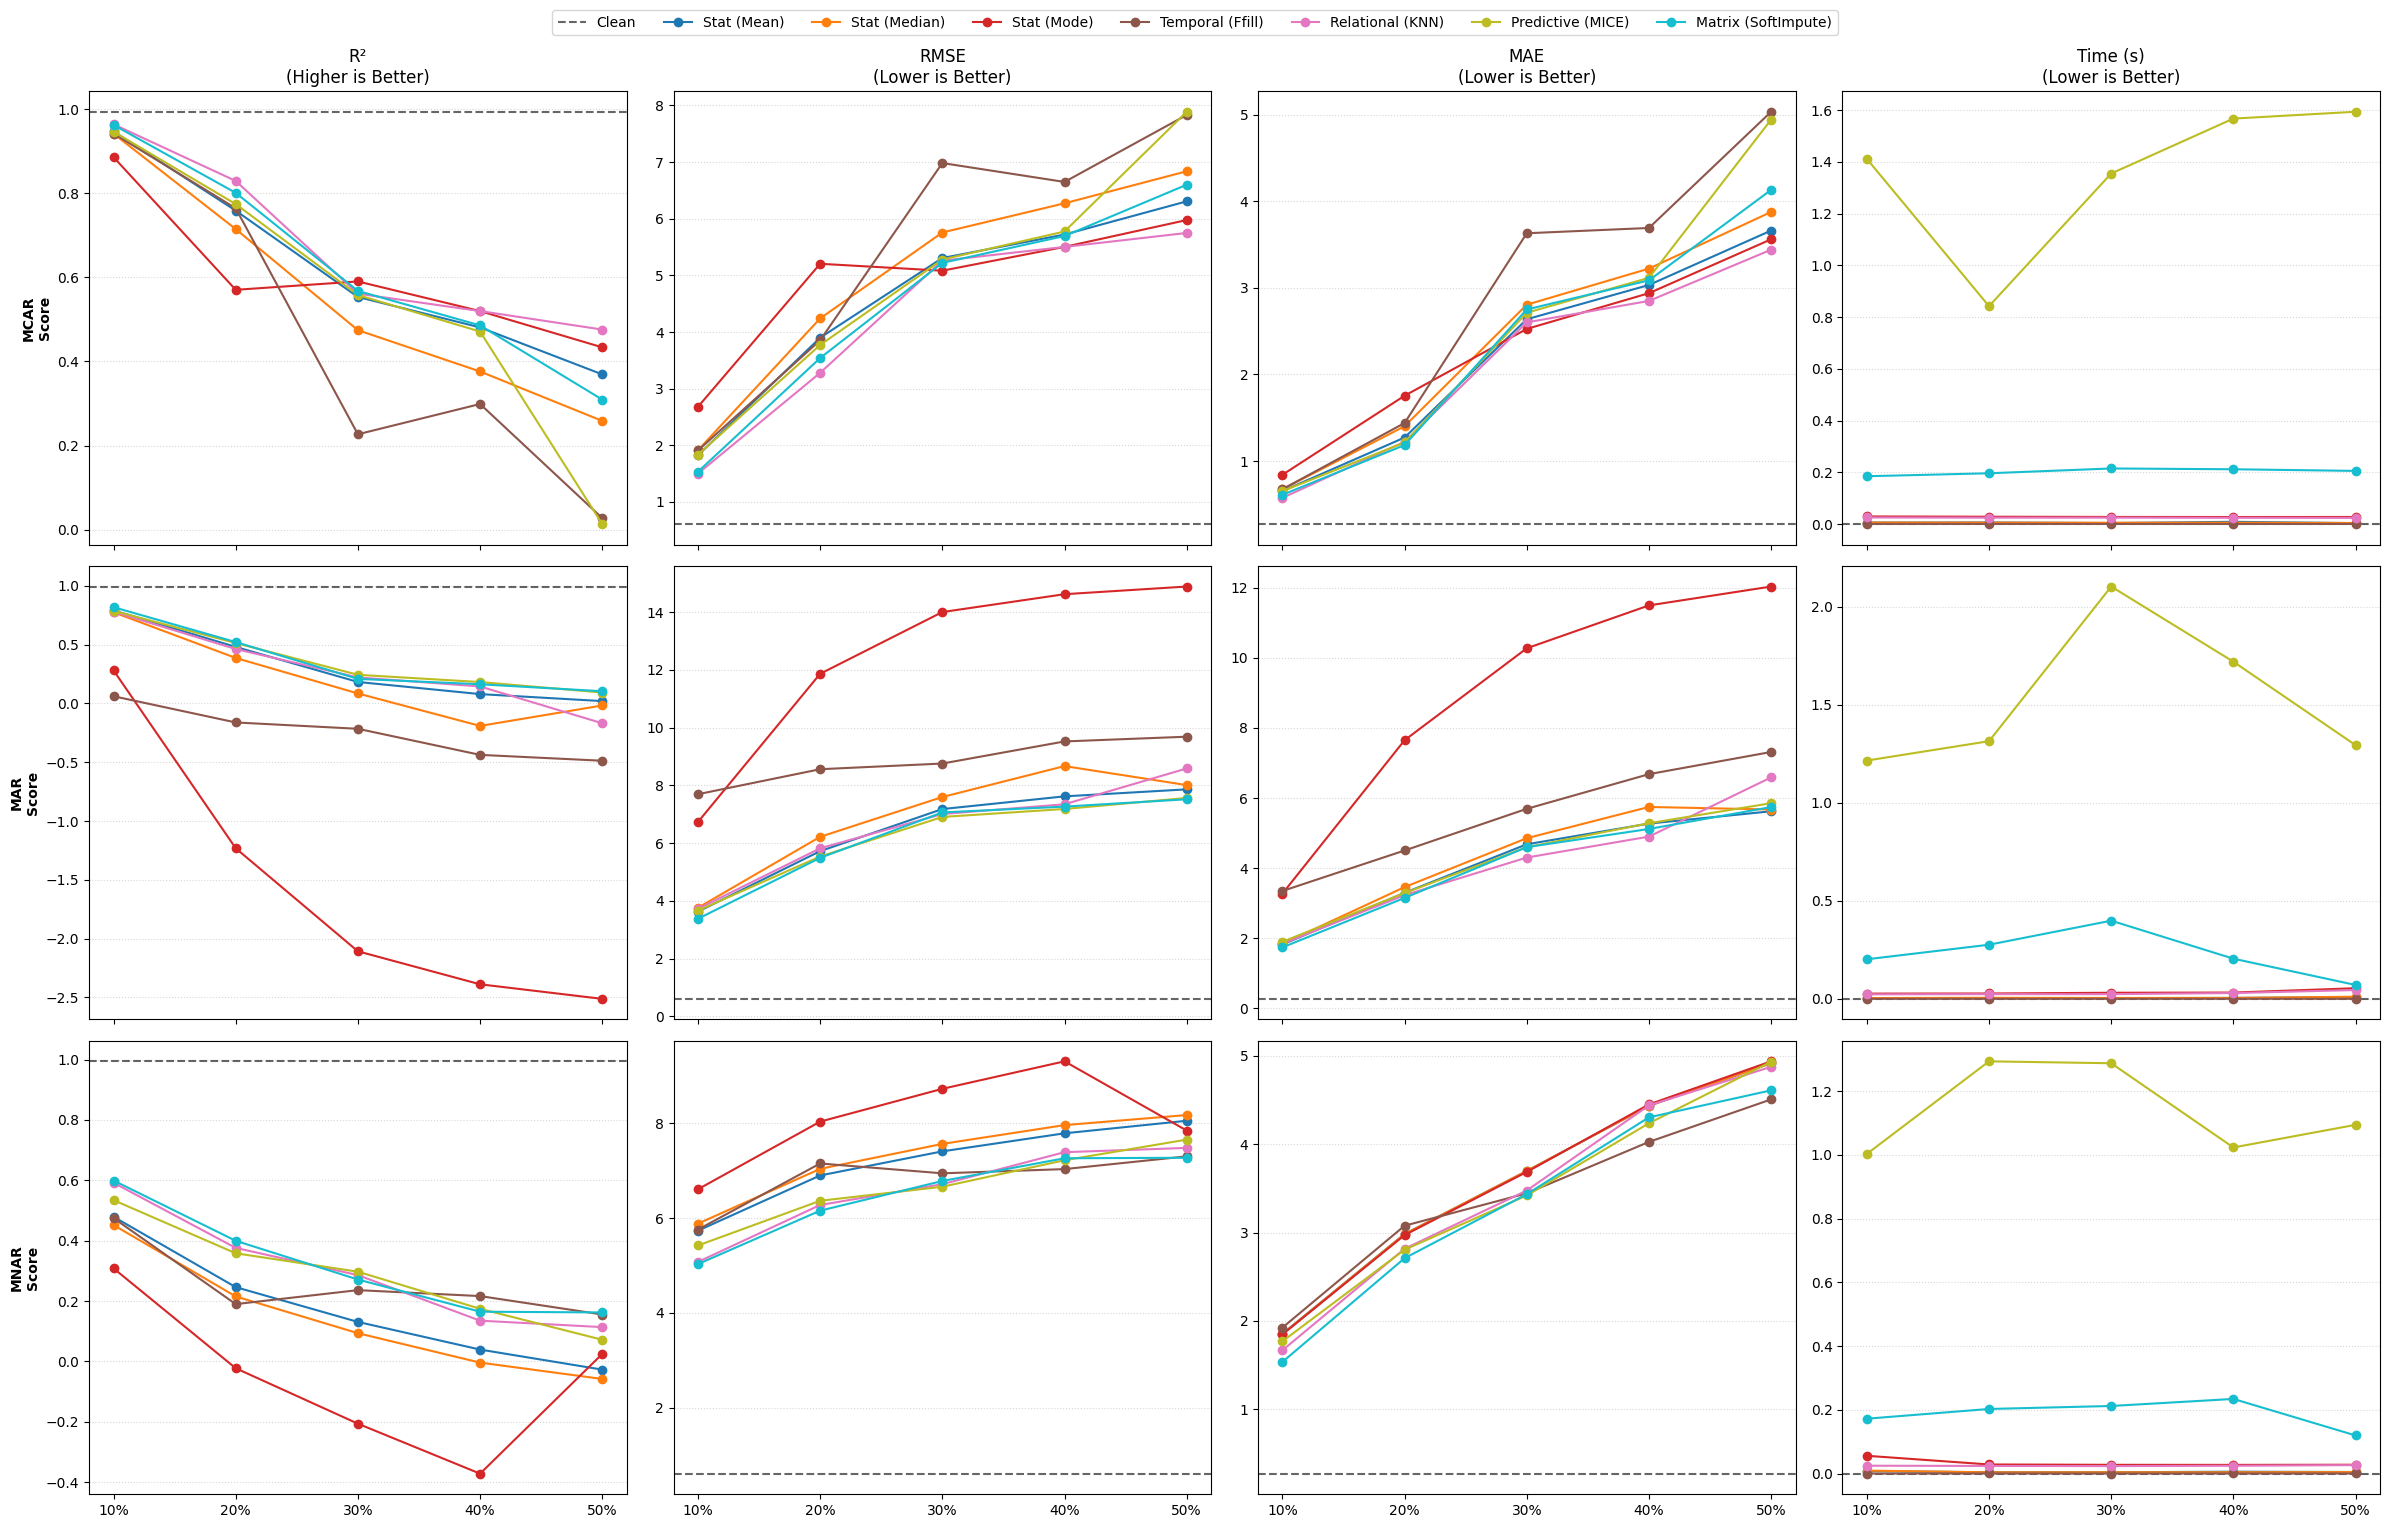

In [81]:
# Prepare data
plot_df = results_df[results_df['Strategy'] != 'Corrupted (Unrepaired)']
missing_types = plot_df['Type'].unique()
metrics = ['R²', 'RMSE', 'MAE', 'Time (s)']
strategies = [s for s in plot_df['Strategy'].unique() if s != 'Clean (Perfect Data)']

fig, axes = plt.subplots(len(missing_types), len(metrics), figsize=(24, 15), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(strategies)))

for row, m_type in enumerate(missing_types):
    type_df = plot_df[plot_df['Type'] == m_type]
    rates_str = sorted(type_df['Rate'].unique())
    rates_num = [int(r.replace('%', '')) for r in rates_str] # Convert rates to numeric for x-axis

    for col, metric in enumerate(metrics):
        ax = axes[row, col]

        # Plot Benchmark Line
        clean_val = plot_df[plot_df['Strategy'] == 'Clean (Perfect Data)'][metric].iloc[0]
        ax.axhline(y=clean_val, color='black', linestyle='--', alpha=0.6, label='Clean')

        # Plot Strategy Lines (slope trend)
        for i, strategy in enumerate(strategies):
            strat_data = type_df[type_df['Strategy'] == strategy]
            # Ensure rates match and get values
            vals = [strat_data[strat_data['Rate'] == r][metric].values[0] for r in rates_str]
            ax.plot(rates_num, vals, marker='o', linestyle='-', label=strategy, color=colors[i])

        if row == 0: ax.set_title(f"{metric}\n(Higher is Better)" if metric == 'R²' else f"{metric}\n(Lower is Better)")
        if col == 0: ax.set_ylabel(f"{m_type}\nScore", fontweight='bold')
        ax.set_xticks(rates_num)
        ax.set_xticklabels(rates_str)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

# Single legend for the whole figure
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(strategies)+1)
plt.tight_layout()
plt.show()

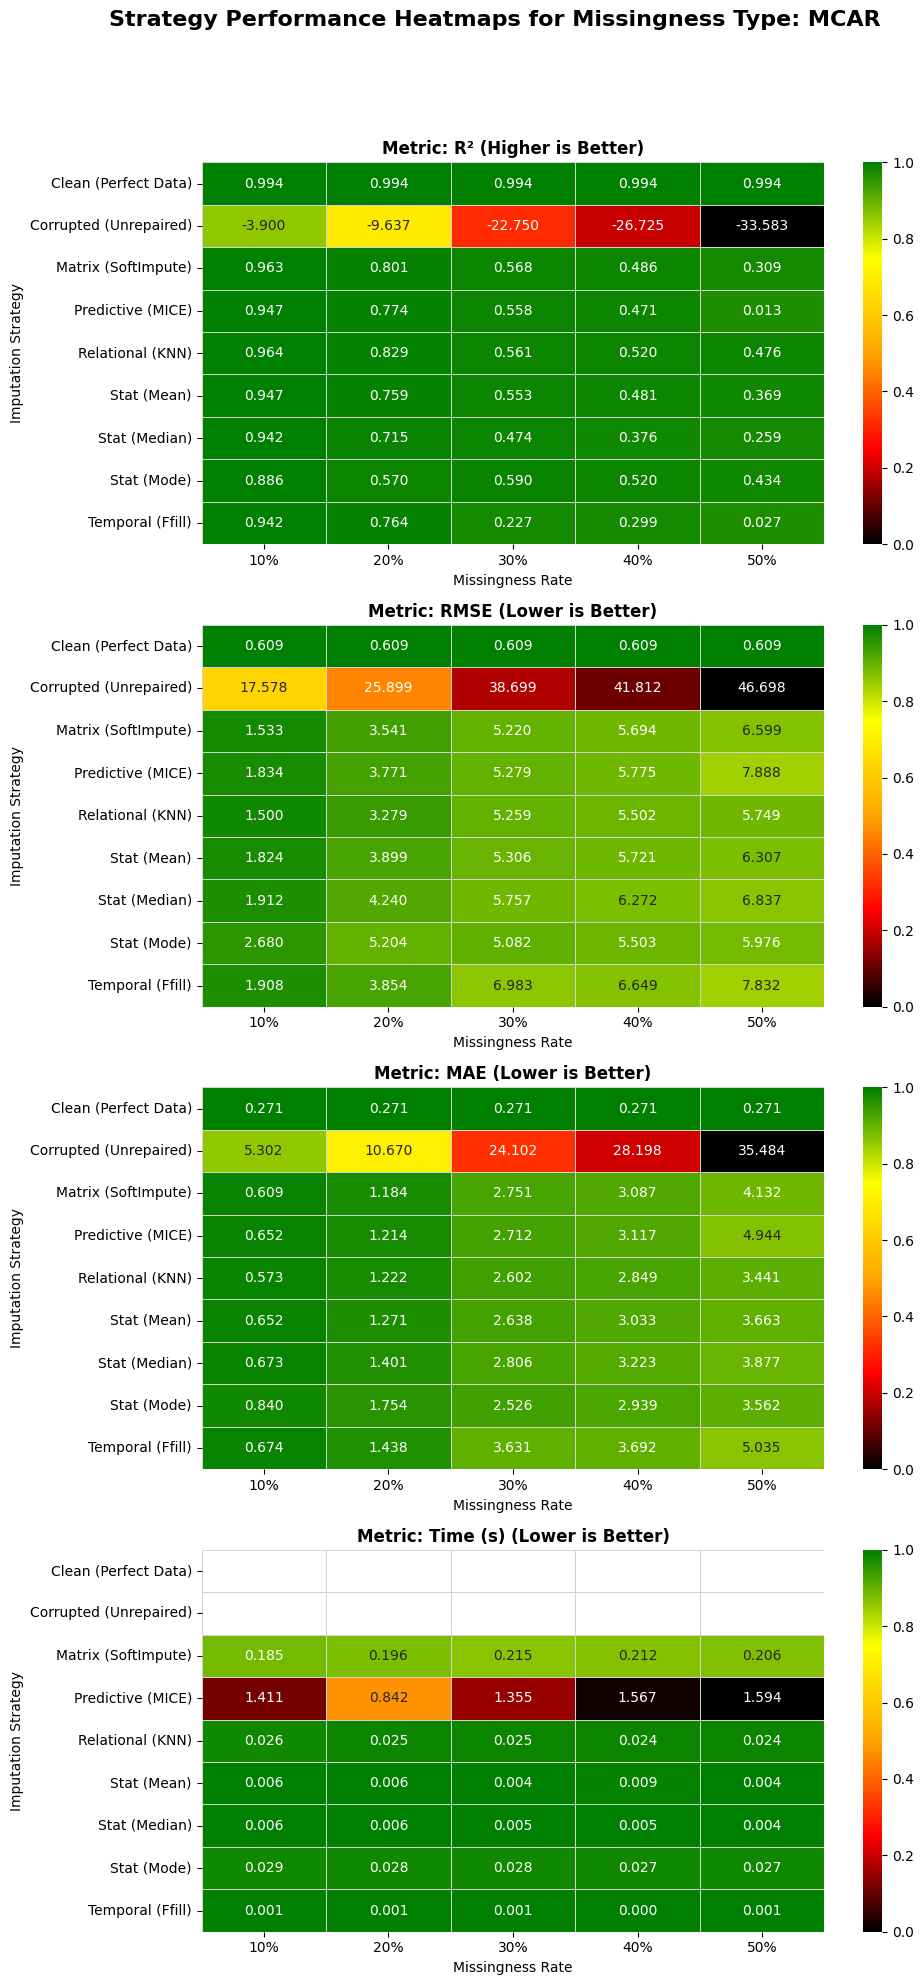

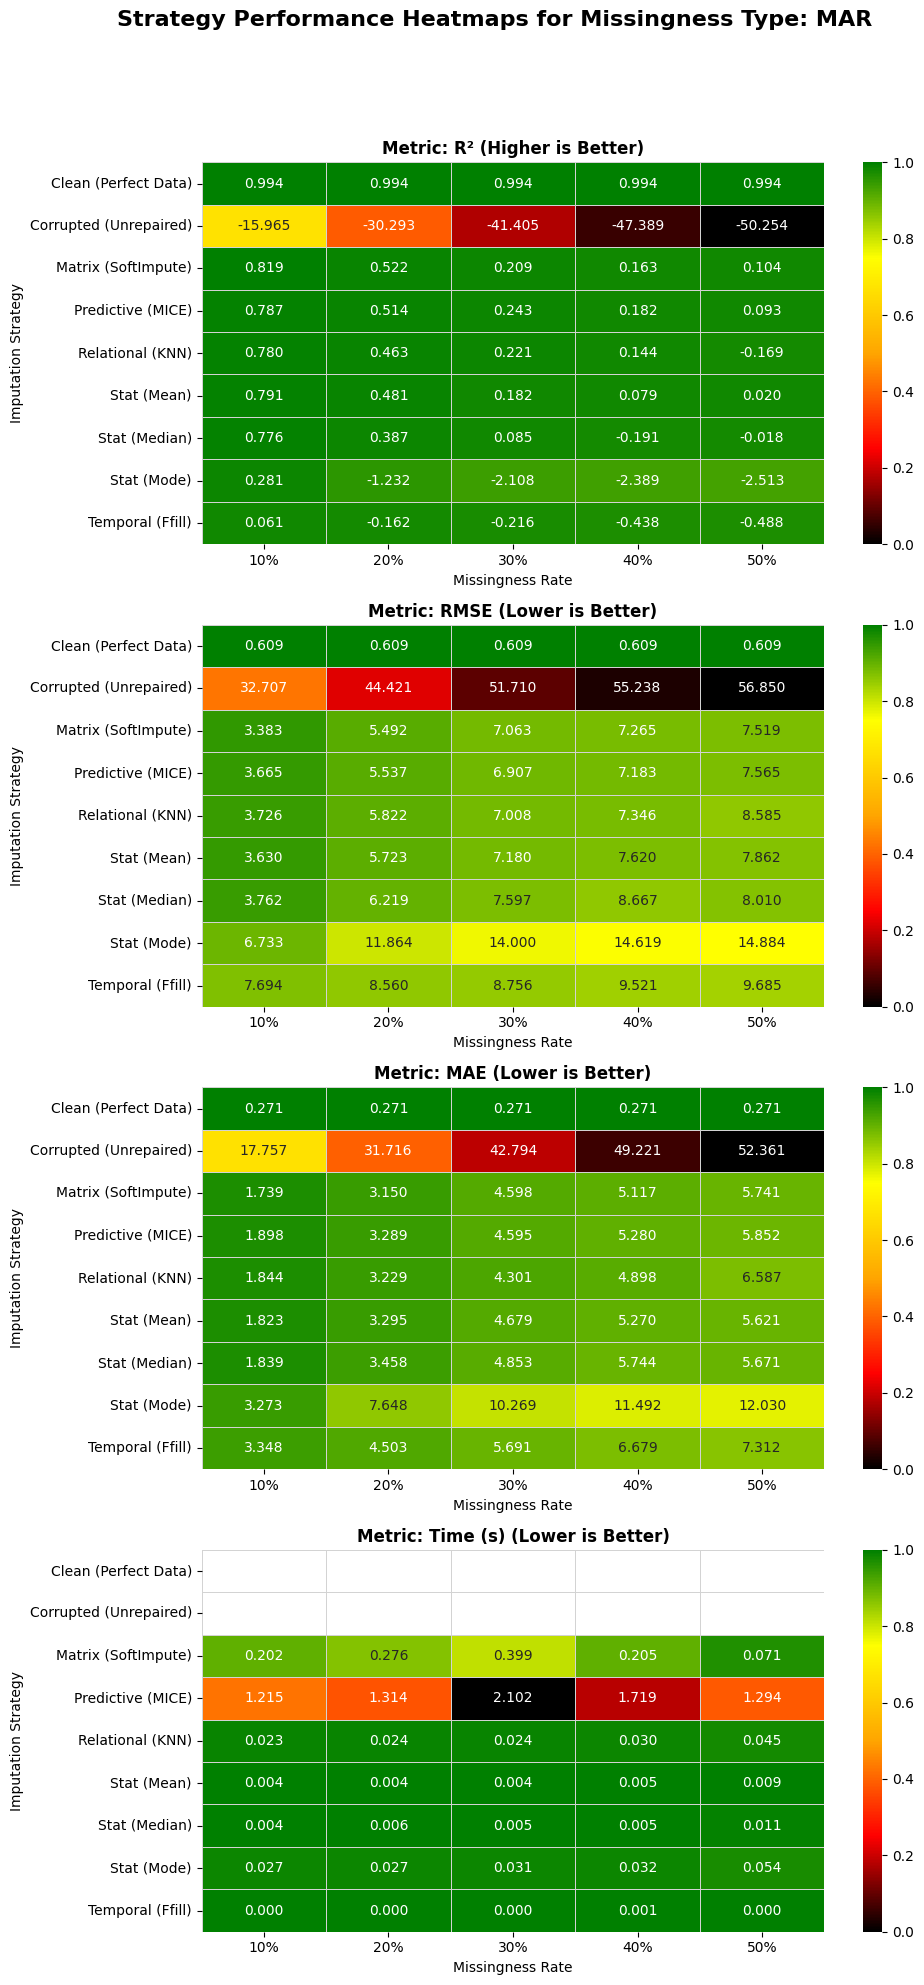

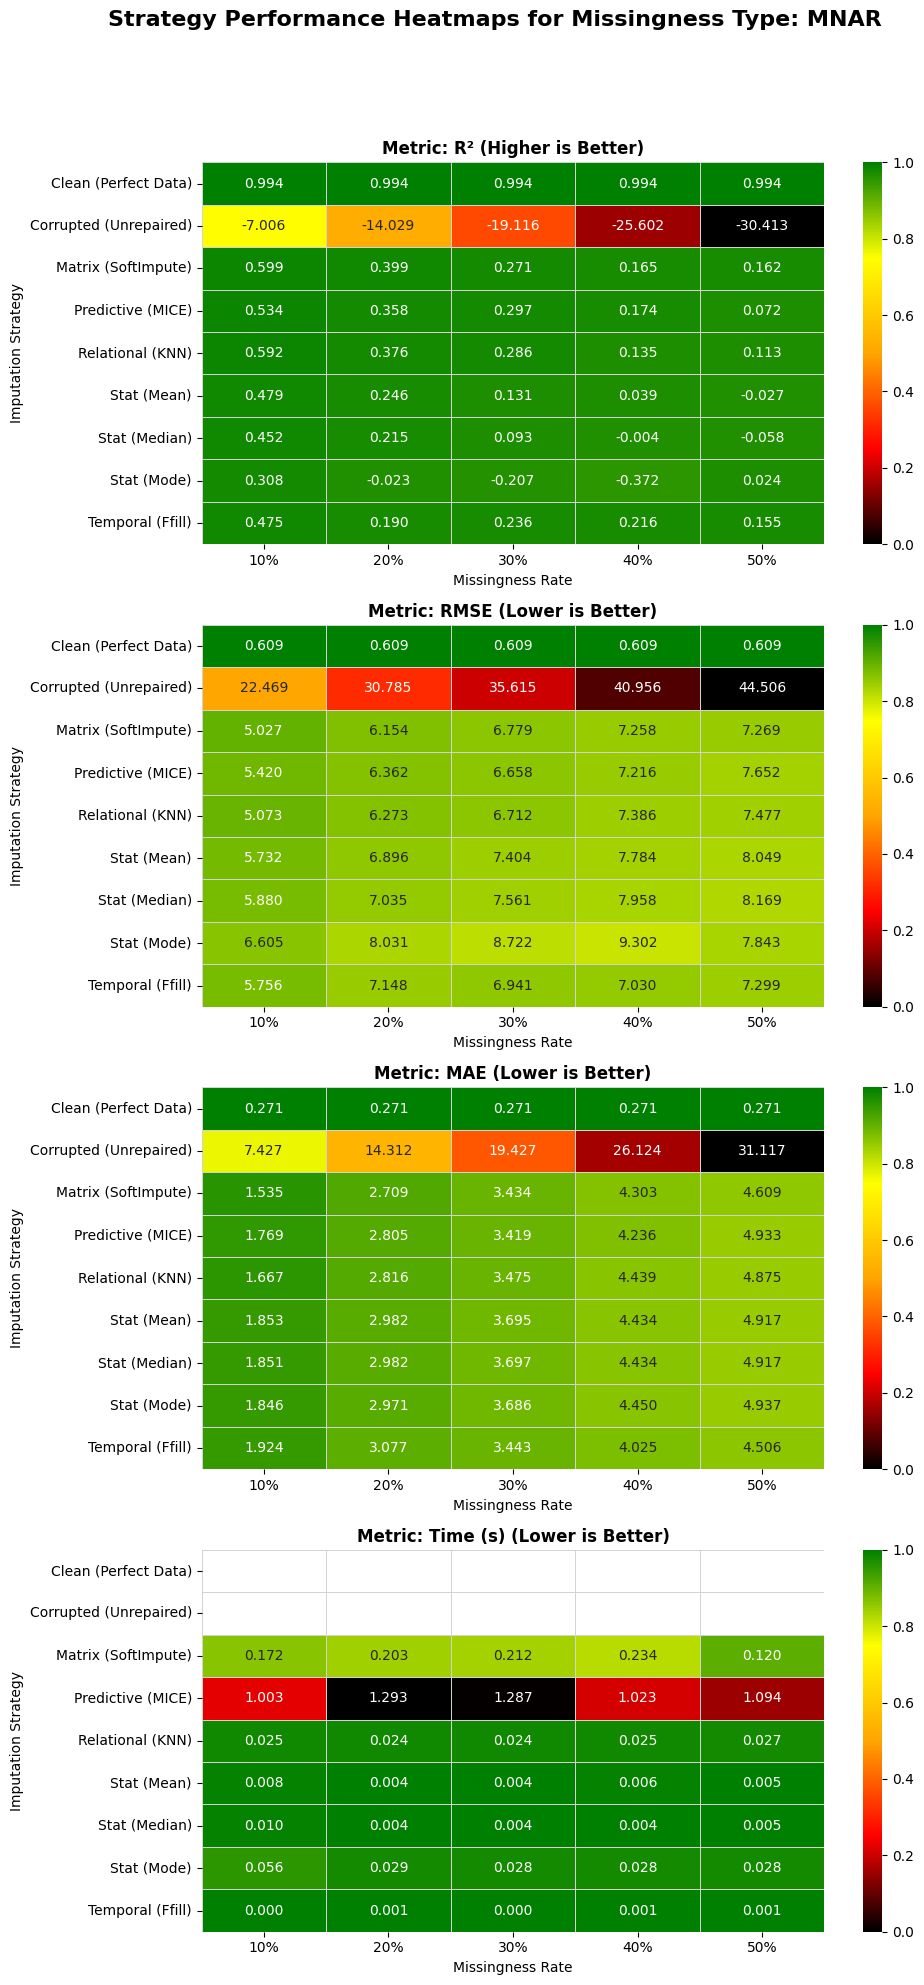

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Explicitly import pandas for pd.CategoricalIndex
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def plot_expanded_heatmaps(df):
    metrics_to_plot = {
        'R²': {'higher_is_better': True},
        'RMSE': {'higher_is_better': False},
        'MAE': {'higher_is_better': False},
        'Time (s)': {'higher_is_better': False}
    }
    missing_types = df['Type'].unique()

    # Define custom colormaps based on Green for better, Black for worse
    # For all metrics: Black (worst) -> Red -> Orange -> Yellow -> Green (best)
    # The normalization ensures that 0 is always 'worst' and 1 is always 'best'.
    custom_cmap = LinearSegmentedColormap.from_list("custom_gradient",
                                                        ["black", "red", "orange", "yellow", "green"])

    # Removed filtering of 'Clean (Perfect Data)' and 'Corrupted (Unrepaired)'
    filtered_df = df.copy()

    # Create a figure for each missingness type, containing subplots for each metric
    for m_type in missing_types:
        fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 5 * len(metrics_to_plot)))
        fig.suptitle(f'Strategy Performance Heatmaps for Missingness Type: {m_type}', fontsize=16, fontweight='bold', y=1.02)
        if len(metrics_to_plot) == 1: # Handle case of single subplot
            axes = [axes]

        for i, (metric, properties) in enumerate(metrics_to_plot.items()):
            ax = axes[i]

            # Filter for the current missingness type
            type_filtered_df = filtered_df[filtered_df['Type'] == m_type]

            # Pivot data: Strategy as index, Rate as columns, metric values
            # Ensure 'Rate' column is sorted numerically for better visualization
            pivot_data = type_filtered_df.pivot_table(index='Strategy', columns='Rate', values=metric, aggfunc='mean')
            pivot_data.columns = pd.CategoricalIndex(pivot_data.columns, ordered=True, categories=sorted(pivot_data.columns, key=lambda x: int(x[:-1])))
            pivot_data = pivot_data.sort_index(axis=1)

            # Prepare data for annotation and normalization
            annot_data = pivot_data.copy()
            norm_data = pivot_data.copy()

            # Special handling for 'Time (s)' to de-emphasize 'Clean' and 'Corrupted'
            if metric == 'Time (s)':
                imputation_strategies = pivot_data[~pivot_data.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])]
                if not imputation_strategies.empty:
                    min_val = imputation_strategies.min().min()
                    max_val = imputation_strategies.max().max()
                else:
                    min_val = 0
                    max_val = 1 # Default if no imputation strategies exist

                if max_val == min_val: # Avoid division by zero
                    # If all imputation strategies have same time, set all to neutral
                    norm_data = 0.5
                else:
                    # Normalize only imputation strategies based on their min/max
                    if properties['higher_is_better']:
                        norm_data[~norm_data.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])] = \
                            (norm_data[~norm_data.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])] - min_val) / (max_val - min_val)
                    else: # lower is better
                        norm_data[~norm_data.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])] = \
                            (max_val - norm_data[~norm_data.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])] ) / (max_val - min_val)

                # Set 'Clean' and 'Corrupted' to NaN in normalized data for coloring, but keep annotation
                norm_data.loc[['Clean (Perfect Data)', 'Corrupted (Unrepaired)'], :] = np.nan

            else: # Standard normalization for other metrics
                min_val = norm_data.min().min()
                max_val = norm_data.max().max()

                if min_val == max_val: # Avoid division by zero if all values are the same
                    norm_data = 0.5 # Neutral color
                elif properties['higher_is_better']:
                    norm_data = (norm_data - min_val) / (max_val - min_val)
                else: # lower is better
                    norm_data = (max_val - norm_data) / (max_val - min_val)

            # Use the single custom colormap as normalization ensures 0=worst, 1=best
            cmap = custom_cmap

            title_suffix = '(Higher is Better)' if properties['higher_is_better'] else '(Lower is Better)'
            sns.heatmap(norm_data, annot=annot_data, fmt=".3f", cmap=cmap, cbar=True, ax=ax, linewidths=.5, linecolor='lightgray')
            ax.set_title(f"Metric: {metric} {title_suffix}", fontweight='bold')
            ax.set_xlabel("Missingness Rate")
            ax.set_ylabel("Imputation Strategy")

        plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
        plt.show()

# Call the function with the results_df
plot_expanded_heatmaps(results_df)

## **7. Detailed Leaderboards**

Here are the detailed leaderboards for RMSE, MAE, R² scores, and Execution Time across different missing rates.

In [86]:
from scipy.stats import mode

def generate_leaderboard(df, metric, missing_type=None, ascending=True):
    """Refactored helper to handle multi-type missingness and pivot.
    Optionally filters by a specific missing_type.
    """

    if missing_type:
        df = df[df['Type'] == missing_type].copy()

    # Group by Strategy and Rate to get unique entries for pivoting
    df_grouped = df.groupby(['Strategy', 'Rate'])[metric].mean().reset_index()

    # Now pivot will work because each Strategy/Rate pair is unique
    pivot = df_grouped.pivot(index="Strategy", columns="Rate", values=metric)

    # Separate Benchmarks
    benchmarks = pivot[pivot.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])]
    strategies = pivot[~pivot.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])].copy()

    # Loop-based Ranking (Robustly handles any number of % columns)
    rate_cols = [c for c in pivot.columns if '%' in str(c)]
    rank_cols = []
    for col in rate_cols:
        rank_name = f'Rank_{col}'
        strategies[rank_name] = strategies[col].rank(ascending=ascending, method='average')
        rank_cols.append(rank_name)

    # Aggregate Ranks
    strategies['Overall_Rank_Avg'] = strategies[rank_cols].mean(axis=1)
    strategies = strategies.sort_values('Overall_Rank_Avg')

    # Final Formatting
    display_df = strategies[rate_cols].copy()
    display_df.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(display_df))])

    final_output = pd.concat([benchmarks.assign(**{'Overall Rank': 'N/A'}), display_df])
    return final_output, strategies['Overall_Rank_Avg']

# --- Leaderboard Generation for Overall Averages Across Missingness Types ---

# --- 1. R² Score Leaderboard (Higher is Better) ---
pivot_r2_overall, strategies_r2_overall = generate_leaderboard(results_df, 'R²', ascending=False)

# --- 2. RMSE Leaderboard (Lower is Better) ---
pivot_rmse_overall, strategies_rmse_overall = generate_leaderboard(results_df, 'RMSE', ascending=True)

# --- 3. MAE Leaderboard (Lower is Better) ---
pivot_mae_overall, strategies_mae_overall = generate_leaderboard(results_df, 'MAE', ascending=True)

# --- 4. Execution Time Leaderboard (Lower is Better) ---
pivot_time_overall, strategies_time_overall = generate_leaderboard(results_df, 'Time (s)', ascending=True)

# --- Overall Conclusive Leaderboard (Mean Average Rank Across All Metrics) ---

# Combine the 'Overall_Rank_Avg' from each individual metric's strategies DataFrame.
combined_ranks_overall = pd.DataFrame({
    'R2_Rank_Avg': strategies_r2_overall,
    'RMSE_Rank_Avg': strategies_rmse_overall,
    'MAE_Rank_Avg': strategies_mae_overall,
    'Time_Rank_Avg': strategies_time_overall
})

# Calculate the ultimate overall mean average rank by averaging the average ranks from each metric.
combined_ranks_overall['Mean_Avg_Rank'] = combined_ranks_overall.mean(axis=1)

# Sort by the mean average rank to get the conclusive leaderboard (lower average rank is better)
conclusive_leaderboard_overall = combined_ranks_overall.sort_values(by='Mean_Avg_Rank', ascending=True).copy()

# Insert a formatted 'Overall Conclusive Rank' column for display
conclusive_leaderboard_overall.insert(0, 'Overall Conclusive Rank', [f'#{i+1}' for i in range(len(conclusive_leaderboard_overall))])

# Format the Mean_Avg_Rank to two decimal places and other ranks to five decimal places for display
conclusive_leaderboard_overall['Mean_Avg_Rank'] = conclusive_leaderboard_overall['Mean_Avg_Rank'].map('{:.2f}'.format)
conclusive_leaderboard_overall['R2_Rank_Avg'] = conclusive_leaderboard_overall['R2_Rank_Avg'].map('{:.2f}'.format)
conclusive_leaderboard_overall['RMSE_Rank_Avg'] = conclusive_leaderboard_overall['RMSE_Rank_Avg'].map('{:.2f}'.format)
conclusive_leaderboard_overall['MAE_Rank_Avg'] = conclusive_leaderboard_overall['MAE_Rank_Avg'].map('{:.2f}'.format)
conclusive_leaderboard_overall['Time_Rank_Avg'] = conclusive_leaderboard_overall['Time_Rank_Avg'].map('{:.2f}'.format)

# Rename columns for display
conclusive_leaderboard_overall.rename(columns={
    'Mean_Avg_Rank': 'Mean Average Rank',
    'R2_Rank_Avg': 'Rank by R2',
    'RMSE_Rank_Avg': 'Rank by RMSE',
    'MAE_Rank_Avg': 'Rank by MAE',
    'Time_Rank_Avg': 'Rank by Time'
}, inplace=True)

# --- Detailed Leaderboards Per Missingness Type ---
missing_types_for_detail = results_df['Type'].unique()
metrics_for_detail = {
    'R²': {'ascending': False},
    'RMSE': {'ascending': True},
    'MAE': {'ascending': True},
    'Time (s)': {'ascending': True}
}

for m_type in missing_types_for_detail:
    print(f"\n" + "="*80)
    print(f"DETAILED LEADERBOARDS FOR MISSINGNESS TYPE: {m_type}")
    print(f"="*80)

    for metric_name, params in metrics_for_detail.items():
        df_lb, _ = generate_leaderboard(results_df, metric_name, missing_type=m_type, ascending=params['ascending'])
        print(f"\nLeaderboard for {metric_name} ({'Higher is Better' if not params['ascending'] else 'Lower is Better'})")
        print(f"-"*len(f"Leaderboard for {metric_name}"))
        # Format all numeric columns (except 'Overall Rank') to .5f for consistency
        for col in df_lb.columns:
            if df_lb[col].dtype in ['float64', 'int64']:
                df_lb[col] = df_lb[col].map('{:.5f}'.format)
        print(df_lb)


print("\n" + "—"*60)
print("ULTIMATE OVERALL CONCLUSIVE LEADERBOARD (Mean Rank Across All Metrics & Missingness Types)")
print("—"*60)
# Display only the requested columns, keeping individual metric ranks for transparency
print(conclusive_leaderboard_overall[['Overall Conclusive Rank', 'Mean Average Rank', 'Rank by R2', 'Rank by RMSE', 'Rank by MAE', 'Rank by Time']])



DETAILED LEADERBOARDS FOR MISSINGNESS TYPE: MCAR

Leaderboard for R² (Higher is Better)
------------------
Rate                         10%       20%        30%        40%        50%  \
Strategy                                                                      
Clean (Perfect Data)     0.99412   0.99412    0.99412    0.99412    0.99412   
Corrupted (Unrepaired)  -3.90013  -9.63748  -22.74967  -26.72534  -33.58279   
Relational (KNN)         0.96431   0.82950    0.56134    0.51989    0.47591   
Matrix (SoftImpute)      0.96275   0.80121    0.56780    0.48578    0.30933   
Stat (Mode)              0.88614   0.57047    0.59037    0.51983    0.43361   
Stat (Mean)              0.94725   0.75888    0.55347    0.48103    0.36926   
Predictive (MICE)        0.94663   0.77445    0.55801    0.47117    0.01314   
Stat (Median)            0.94201   0.71494    0.47447    0.37615    0.25860   
Temporal (Ffill)         0.94226   0.76442    0.22677    0.29883    0.02735   

Rate                  

### **8. Visualizing the Guess vs. The Truth**
This cell provides a direct visual comparison of actual target values against the predictions made after imputation by a select few strategies. It helps to intuitively understand how well each strategy reconstructs the underlying signal.

1.  **Ground Truth Plot**: The actual `y_test` values (first 60 samples) are plotted as a thick black line, representing the 'ACTUAL TRUTH'.
2.  **Candidate Strategies**: A list `candidates` is chosen for visual comparison, focusing on a few representative imputation methods.
3.  **Prediction Plots**: For each candidate strategy, the first 60 predicted values from the `prediction_samples` dictionary (which contains predictions at a 20% failure rate) are plotted as dashed lines. This allows for a direct visual assessment of how closely the imputed predictions track the true values.

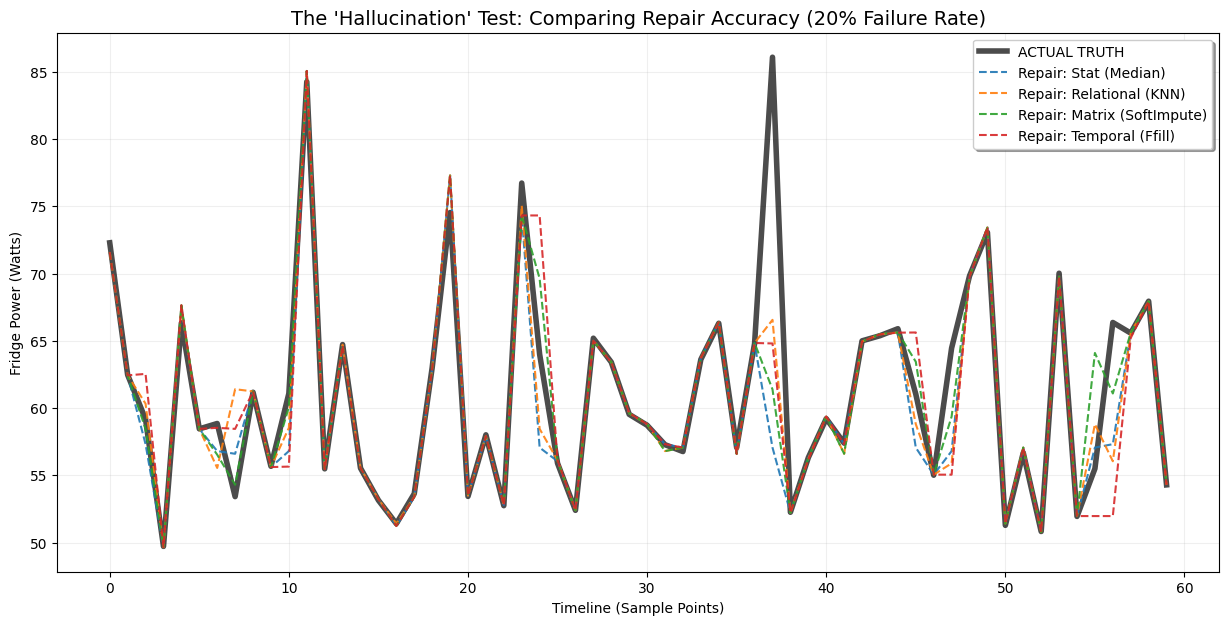

In [84]:
plt.figure(figsize=(15, 7))

#WILL FIX THIS LATER

# Plot the Ground Truth
plt.plot(y_test.values[:60], label='ACTUAL TRUTH', color='black', linewidth=4, alpha=0.7)

# Select key candidates for the visual battle
candidates = ["Stat (Median)", "Relational (KNN)", "Matrix (SoftImpute)", "Temporal (Ffill)"]

for c in candidates:
    plt.plot(prediction_samples[c][:60], label=f'Repair: {c}', linestyle='--', alpha=0.9)

plt.title("The 'Hallucination' Test: Comparing Repair Accuracy (20% Failure Rate)", fontsize=14)
plt.ylabel("Fridge Power (Watts)")
plt.xlabel("Timeline (Sample Points)")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.show()